In [1]:
import torch
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"


from src.LM.lm_slovakBERT import (
    tokenizer, model,
    create_dataloaders,
    train_model,
    evaluate_model,
    get_class_weights
)

from src.data_loader import load_data
from src.preprocess import clean_text


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at gerulata/slovakbert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [2]:
df = load_data("/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv")
df['Text'] = df['Text'].apply(clean_text)  

le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])

# ulozenie katagorii
target_names = le.classes_.tolist()

print("Target names:", target_names)
print("Label distribution:")
print(df["Category_encoded"].value_counts())





Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...
Target names: [0, 1]
Label distribution:
Category_encoded
0    505
1    189
Name: count, dtype: int64


In [3]:
# rozdelenie datasetu
X_train_text, X_test_text, y_train_encoded, y_test_encoded = train_test_split(
    df['Text'].tolist(), 
    df['Category_encoded'].tolist(),
    test_size=0.2, 
    random_state=42,
    stratify=df['Category_encoded']
)
print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

Train size: 555
Test size: 139


In [4]:
train_loader, test_loader = create_dataloaders(
    X_train_text,
    y_train_encoded,
    X_test_text,
    y_test_encoded,
    batch_size=16
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_weights = get_class_weights(y_train_encoded, device)
print("Class weights:", class_weights)


Class weights: tensor([0.6869, 1.8377], device='cuda:0')


Epoch 1/7, Loss: 0.1543
Epoch 2/7, Loss: 0.1122
Epoch 3/7, Loss: 0.0845
Epoch 4/7, Loss: 0.0808
Epoch 5/7, Loss: 0.0473
Epoch 6/7, Loss: 0.0371
Epoch 7/7, Loss: 0.0308
Best threshold (F1-optimal): 0.600
Best F1 score: 0.747| Precision: 0.689 | Recall: 0.816

Recall-optimal threshold: 0.307
F1: 0.655 | Precision: 0.500 | Recall: 0.947
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       101
           1       0.69      0.82      0.75        38

    accuracy                           0.85       139
   macro avg       0.81      0.84      0.82       139
weighted avg       0.86      0.85      0.85       139



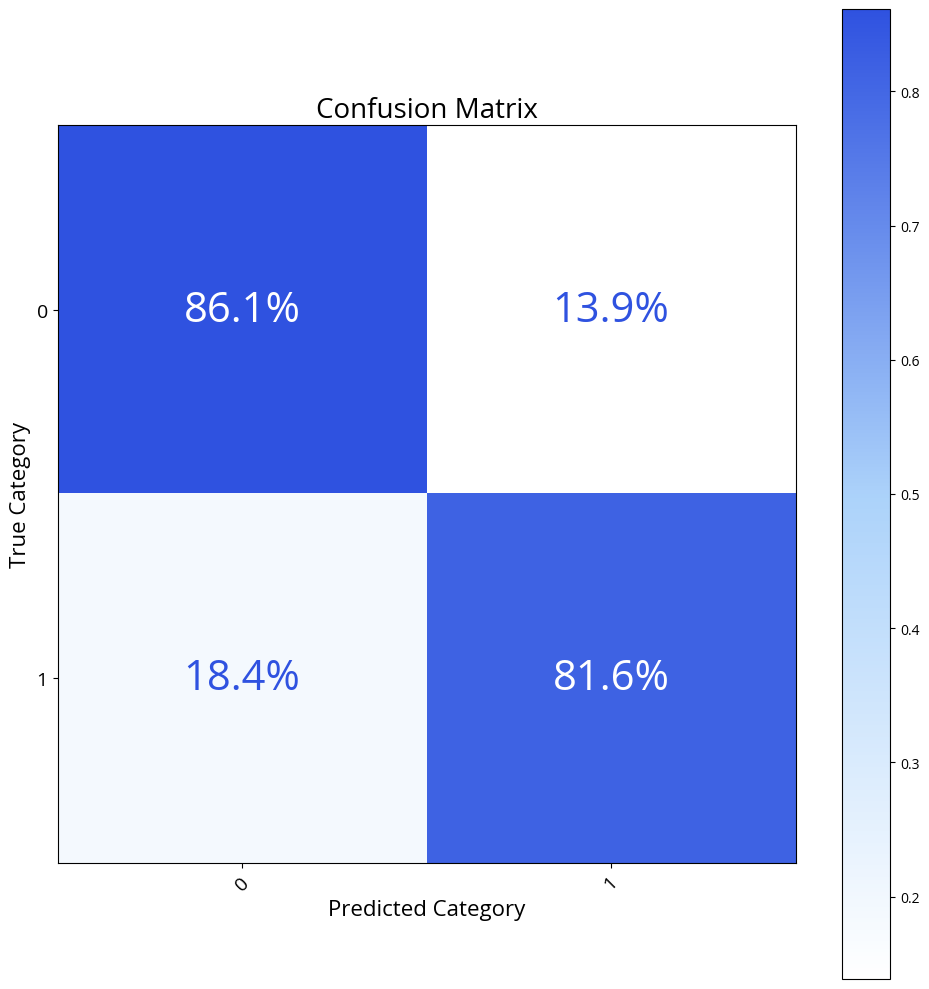

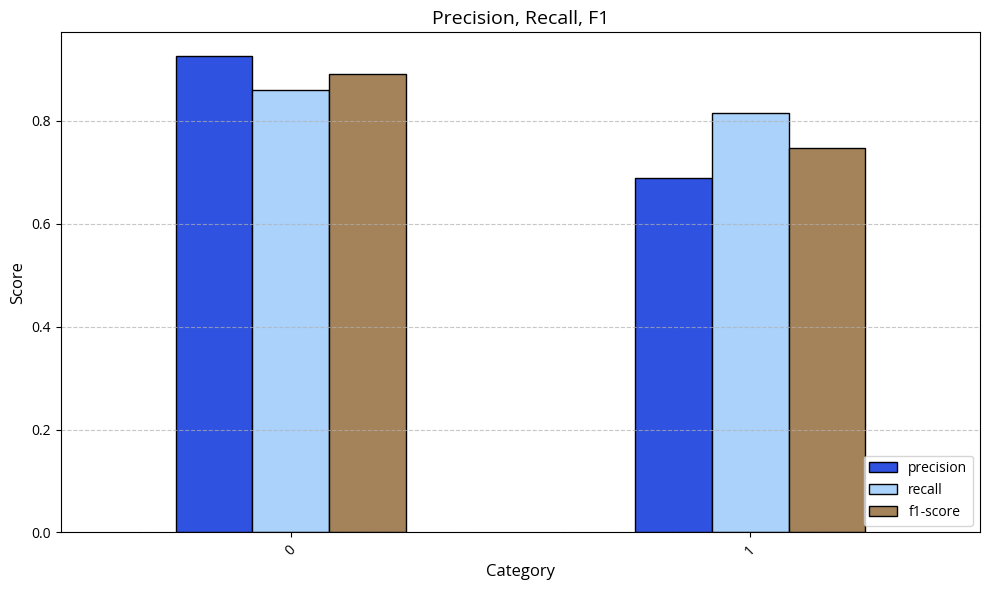

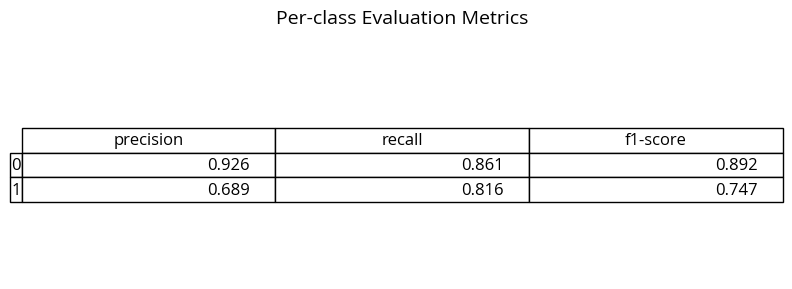

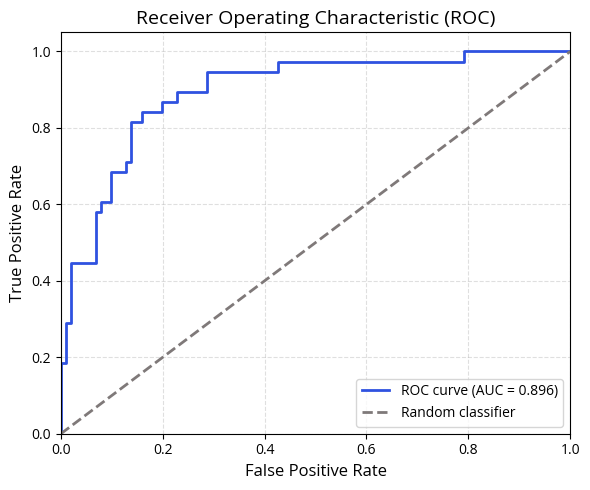

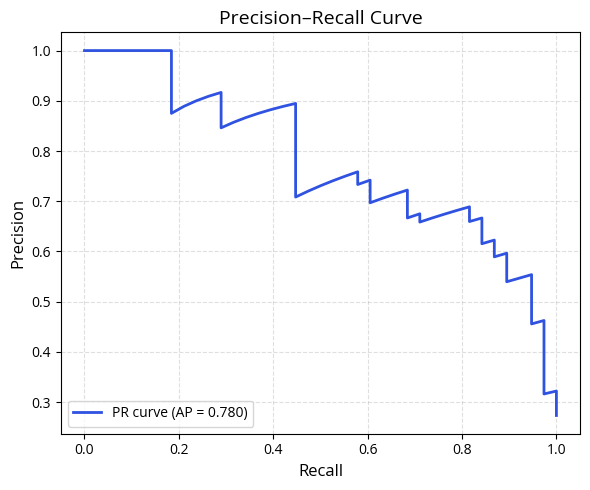

In [5]:
trained_model = train_model(
    model,
    train_loader,
    epochs=7,
    lr=1e-5, 
    use_focal_loss=True,
    class_weights=class_weights
)

trained_model.save_pretrained("models/slovakBert_binary")
tokenizer.save_pretrained("models/slovakBert_binary")

evaluate_model(
    trained_model,
    test_loader,
    label_names=target_names
)


RobertaSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


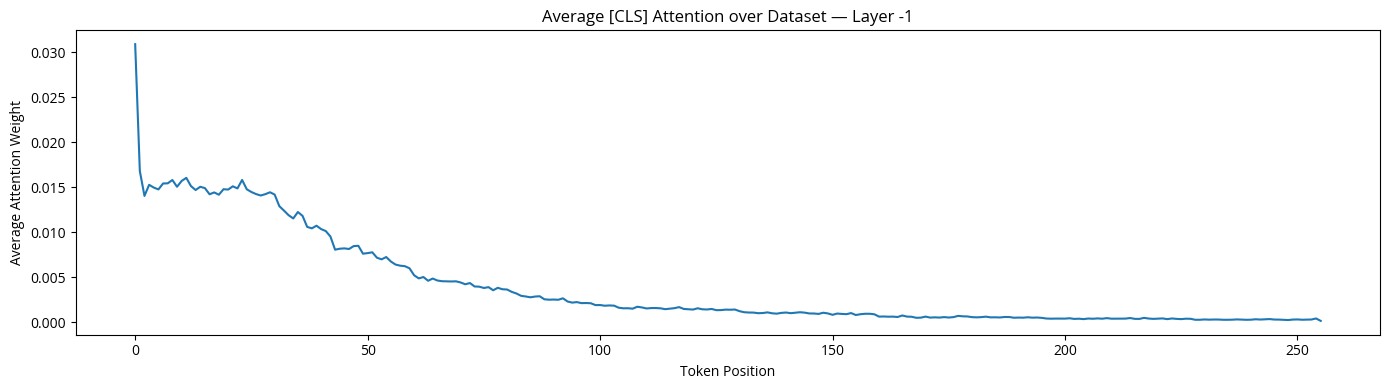

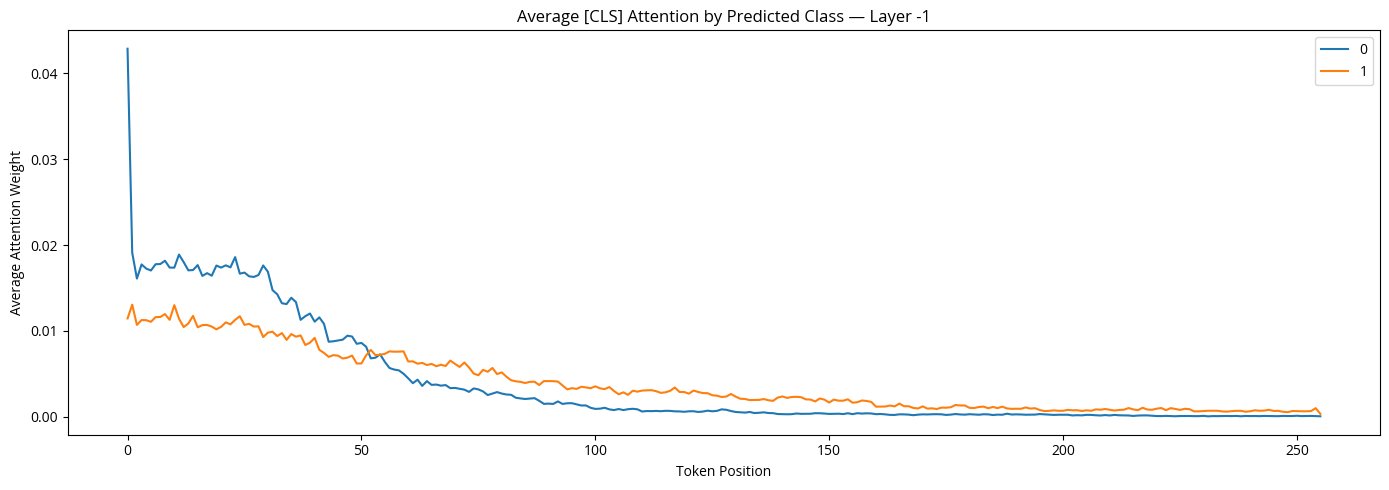

In [6]:
# %%
# === ATTENTION VISUALIZATION ===
import numpy as np
import matplotlib.pyplot as plt

def plot_avg_positional_attention(model, test_loader, device, layer=-1):
    model.eval()
    all_cls_attentions = []

    with torch.no_grad():
        for batch in test_loader:
            input_batch = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
            outputs = model(**input_batch, output_attentions=True)

            attn_layer = outputs.attentions[layer]           # [batch, heads, seq, seq]
            cls_attn = attn_layer[:, :, 0, :].mean(dim=1)   # [batch, seq]
            all_cls_attentions.append(cls_attn.cpu().numpy())

    all_cls_attentions = np.vstack(all_cls_attentions)
    avg_attn = all_cls_attentions.mean(axis=0)
    avg_attn = avg_attn / avg_attn.sum()

    plt.figure(figsize=(14, 4))
    plt.plot(avg_attn)
    plt.xlabel("Token Position")
    plt.ylabel("Average Attention Weight")
    plt.title(f"Average [CLS] Attention over Dataset — Layer {layer}")
    plt.tight_layout()
    plt.show()


def plot_classwise_attention(model, test_loader, device, target_names, layer=-1):
    model.eval()
    attn_by_class = {0: [], 1: []}

    with torch.no_grad():
        for batch in test_loader:
            input_batch = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
            outputs = model(**input_batch, output_attentions=True)

            attn_layer = outputs.attentions[layer]
            cls_attn = attn_layer[:, :, 0, :].mean(dim=1).cpu().numpy()
            preds = outputs.logits.argmax(dim=1).cpu().numpy()

            for i, pred in enumerate(preds):
                attn_by_class[pred].append(cls_attn[i])

    plt.figure(figsize=(14, 5))
    for cls_idx, cls_name in enumerate(target_names):
        attns = np.array(attn_by_class[cls_idx])
        avg = attns.mean(axis=0)
        avg = avg / avg.sum()
        plt.plot(avg, label=cls_name)

    plt.xlabel("Token Position")
    plt.ylabel("Average Attention Weight")
    plt.title(f"Average [CLS] Attention by Predicted Class — Layer {layer}")
    plt.legend()
    plt.tight_layout()
    plt.show()


# %%
plot_avg_positional_attention(trained_model, test_loader, device, layer=-1)
plot_classwise_attention(trained_model, test_loader, device, target_names, layer=-1)

Decoded words: ['najlepších', 'zliav', 'tohto', 'týždňa', 's', 'priemernou', 'výškou', 'vyše', 'aj', 'tento']


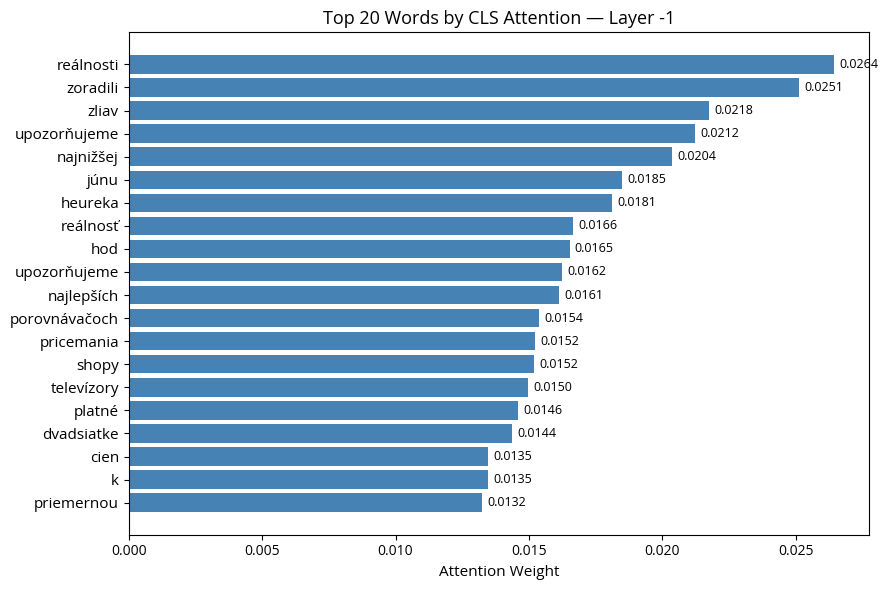


Sample text: najlepších zliav tohto týždňa s priemernou výškou vyše aj tento týždeň sme produkty zoradili podľa ceny od najnižšej ceny sú platné k a hod opäť upozorňujeme aby ste si dávali pozor na ceny pred každou kúpou preto odporúčame si reálnosť ceny skontrolovať na heureka sk alebo pricemania sk najväčších slovenských porovnávačoch cien tie síce neobsahujú všetky e shopy slovenska no pre predstavu reálnosti cien sú výborné upozorňujeme že dostupnosť produktov a ich ceny sú platné k dnešku júnu k hod v top dvadsiatke nájdete nie len led žiarovky či drobnosti a doplnky k smartfónom a počítačom ale aj smart zariadenia do domácnosti či televízory za tie najlepšie ceny

Top 20 attended words:
  reálnosti                 0.0264
  zoradili                  0.0251
  zliav                     0.0218
  upozorňujeme              0.0212
  najnižšej                 0.0204
  júnu                      0.0185
  heureka                   0.0181
  reálnosť                  0.0166
  hod            

In [7]:



def get_word_attentions(text, model, tokenizer, device, layer=-1, max_length=256):
    model.eval()

    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='pt'
    )
    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(**encoding, output_attentions=True)

    attentions = outputs.attentions[layer]
    cls_attn = attentions[0, :, 0, :].mean(dim=0).cpu().numpy()

    input_ids = encoding['input_ids'][0]
    mask = encoding['attention_mask'][0].cpu().numpy()
    seq_len = int(mask.sum())

    # decode each token individually
    raw_tokens = [tokenizer.decode([input_ids[i]]) for i in range(seq_len)]
    cls_attn = cls_attn[:seq_len]
    cls_attn = cls_attn / cls_attn.sum()

    # merge subword tokens into full words
    # in byte-level BPE, a token that starts with a space = new word
    words = []
    scores = []
    current_word = ""
    current_score = 0.0

    for token, score in zip(raw_tokens, cls_attn):
        # skip special tokens
        if token.strip() in ['<s>', '</s>', '<pad>']:
            continue

        if token.startswith(' ') or current_word == "":
            # new word starts — save previous
            if current_word.strip():
                words.append(current_word.strip())
                scores.append(current_score)
            current_word = token
            current_score = score
        else:
            # continuation of current word
            current_word += token
            current_score += score

    # save last word
    if current_word.strip():
        words.append(current_word.strip())
        scores.append(current_score)

    scores = np.array(scores)
    scores = scores / scores.sum()

    return words, scores


def plot_cls_top_words(text, model, tokenizer, device, layer=-1, max_length=256, top_k=20):
    words, word_attn = get_word_attentions(text, model, tokenizer, device, layer, max_length)

    top_indices = word_attn.argsort()[-top_k:][::-1]
    top_words = [words[i] for i in top_indices]
    top_scores = word_attn[top_indices]

    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.barh(range(len(top_words)), top_scores[::-1], color='steelblue')
    ax.set_yticks(range(len(top_words)))
    ax.set_yticklabels(top_words[::-1], fontsize=11)
    ax.set_xlabel("Attention Weight", fontsize=11)
    ax.set_title(f"Top {top_k} Words by CLS Attention — Layer {layer}", fontsize=13)

    for bar, score in zip(bars, top_scores[::-1]):
        ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height() / 2,
                f'{score:.4f}', va='center', fontsize=9)

    plt.tight_layout()
    display(fig)
    plt.close()

    print("\nSample text:", text)
    print(f"\nTop {top_k} attended words:")
    for w, s in zip(top_words, top_scores):
        print(f"  {w:25s} {s:.4f}")


# %%
# verify tokens look correct before plotting
words, scores = get_word_attentions(X_test_text[0], trained_model, tokenizer, device)
print("Decoded words:", words[:10])

# %%
plot_cls_top_words(X_test_text[0], model, tokenizer, device)

from IPython.display import display, HTML

def plot_inline_attention(text, model, tokenizer, device, layer=-1, max_length=256, sample_idx = None, top_k=20):
    """
    Displays the sentence with each word highlighted by attention intensity.
    Darker = higher attention.
    """
    words, scores = get_word_attentions(text, model, tokenizer, device, layer, max_length)

    # get prediction
    model.eval()
    encoding = tokenizer(text, truncation=True, padding='max_length',
                         max_length=max_length, return_tensors='pt')
    encoding = {k: v.to(device) for k, v in encoding.items()}
    with torch.no_grad():
        outputs = model(**encoding, output_attentions=True)
    pred_idx = outputs.logits.argmax(dim=1).item()
    pred_label = target_names[pred_idx]
    confidence = torch.softmax(outputs.logits, dim=1)[0][pred_idx].item()
    # model outputs -> logits 
    # logits -> probabilities (using softmax)

    sample_label = f"Sample number: {sample_idx}" if sample_idx is not None else ""
    # normalize scores to 0-1
    min_s, max_s = scores.min(), scores.max()
    normalized = (scores - min_s) / (max_s - min_s + 1e-8)

    top_k_indices = set(np.argsort(scores)[-top_k:])
    # build HTML
    html = f"""
    <div style="font-family: Corbel, serif; max-width: 860px; padding: 20px;
                border: 1px solid #ddd; border-radius: 8px; margin: 10px 0;
                background: #fafafa;">
        <div style="margin-bottom: 12px; font-size: 13px; color: #555;">
            <b style="color:#222">{sample_label}</b>
            &nbsp;|&nbsp;
            Predicted: <b style="color:#222">{pred_label}</b>
            &nbsp;|&nbsp;
            Confidence: <b style="color:#222">{confidence:.1%}</b>
            &nbsp;|&nbsp;
            Layer: {layer}
        </div>
        <div style="line-height: 2.8; font-size: 15px;">
    """

    for idx, (word, score) in enumerate(zip(words, normalized)):
        if idx in top_k_indices:
            r = int(255)
            g = int(255 - 220 * score)
            b = int(255 - 220 * score)
            bg = f"rgb({r},{g},{b})"
            text_color = "#000" if score < 0.7 else "#fff"
            opacity = 0.15 + 0.85 * score

            html += f"""<span style="
                background-color: {bg};
                opacity: {opacity:.2f};
                color: {text_color};
                padding: 2px 5px;
                margin: 2px 2px;
                border-radius: 4px;
                display: inline-block;
                font-weight: {'600' if score > 0.6 else '400'};
            ">{word}</span> """

    html += "</div></div>"
    display(HTML(html))


# %%
# single sentence
plot_inline_attention(X_test_text[0], trained_model, tokenizer, device)

# %%
# or loop over several examples — mix of both classes
for i in [0, 2, 5, 8, 12]:
    plot_inline_attention(X_test_text[i], trained_model, tokenizer, device, sample_idx=i)